In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import OpenDHW

In [2]:
occ = pd.read_csv(r"C:\Users\Samuel\PycharmProjects\DistrictGenerator2\districtgenerator\districtgenerator\results\demands\test_0_SFH_timeseries.csv", delimiter=';')

occ.occ.mean()


np.float64(2.0328386605783866)

In [3]:
occ = occ.occ/ occ.occ.max()

In [4]:
occ

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
525595    1.0
525596    1.0
525597    1.0
525598    1.0
525599    1.0
Name: occ, Length: 525600, dtype: float64

In [5]:
# 1. Feiertage laden
holidays = OpenDHW.get_holidays(country_code="DE", year=2019)

In [51]:
timeseries_df = OpenDHW.generate_dhw_profile_new(
    s_step=60,                        # Zeitschritt in Sekunden
    categories=1,
    occupancy=5,                      # Anzahl Personen
    building_type="SFH",              # SFH, TH, MFH, AB, SC, OB, GS, RE
    weekend_weekday_factor=1.2,       # nur für Wohngebäude
    holidays=holidays,
    mean_drawoff_vol_per_day=40,      # L/(Person*Tag)
    initial_day=1 ,                    # 0=Montag, 1=Dienstag, …
    occupancy_series=occ

)

# 3. Wärme berechnen
timeseries_df = OpenDHW.compute_heat(timeseries_df=timeseries_df, temp_dT=35)

# 4. Ergebnisse verwenden
water_series = timeseries_df['Water_L']
heat_series  = timeseries_df['Heat_kWh']

525600
525600


In [52]:
timeseries_df

,p_norm_integral,Water_LperH,Water_LperH_cat480,Water_L_cat480,Water_L,method,categories,initial_day,weekend_weekday_factor,mean_drawoff_vol_per_day,Heat_W,Heat_kW,Heat_J,Heat_kWh
2019-01-01 00:00:00,6.702177e-07,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:01:00,1.340435e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:02:00,2.010653e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:03:00,2.680871e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:04:00,3.351089e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 23:55:00,9.999987e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-12-31 23:56:00,9.999990e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-12-31 23:57:00,9.999993e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-12-31 23:58:00,9.999997e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0


In [53]:
timeseries_df

,p_norm_integral,Water_LperH,Water_LperH_cat480,Water_L_cat480,Water_L,method,categories,initial_day,weekend_weekday_factor,mean_drawoff_vol_per_day,Heat_W,Heat_kW,Heat_J,Heat_kWh
2019-01-01 00:00:00,6.702177e-07,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:01:00,1.340435e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:02:00,2.010653e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:03:00,2.680871e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-01-01 00:04:00,3.351089e-06,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 23:55:00,9.999987e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-12-31 23:56:00,9.999990e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-12-31 23:57:00,9.999993e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0
2019-12-31 23:58:00,9.999997e-01,0,0,0.0,0.0,OpenDHW,1,1,1.2,200,0.0,0.0,0.0,0.0


In [54]:
timeseries_df.index > "2019-01-01 00:00:00"

array([False,  True,  True, ...,  True,  True,  True], shape=(525600,))

In [55]:
timeseries_df["occ"]  = np.array(occ)

In [66]:
date = "2019-01-04 00:00:00"
date2 = "2019-01-03 00:00:00"

In [67]:
(timeseries_df.index < date) & (timeseries_df.index > date2)

array([False, False, False, ..., False, False, False], shape=(525600,))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

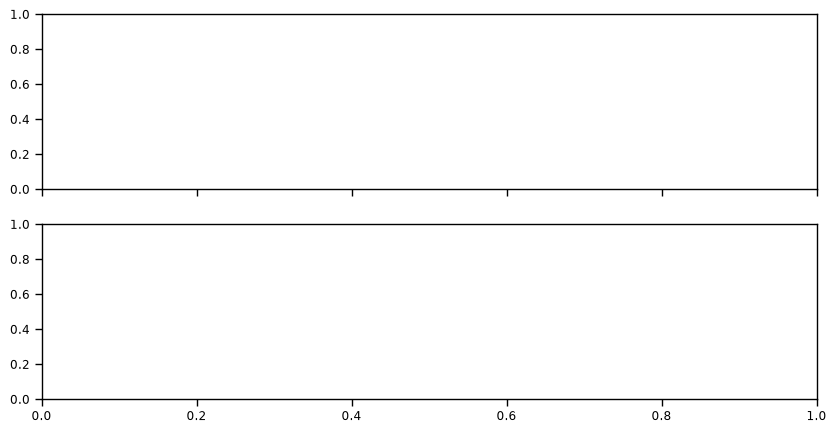

In [60]:
fig, [ax1,ax2] = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 5))
ax1.plot(timeseries_df.loc[timeseries_df.index < date and timeseries_df.index > date2].index,timeseries_df.loc[timeseries_df.index < date and timeseries_df.index > date2,"Heat_kW"])
ax2.plot(timeseries_df.loc[timeseries_df.index < date].index, timeseries_df.loc[timeseries_df.index < date,"occ"])

In [10]:
res = OpenDHW.generate_yearly_probability_profile(s_step=60,weekend_weekday_factor=1.2,building_type="SFH",holidays=holidays,initial_day=0)

In [11]:
res

,p_norm_integral
2019-01-01 00:00:00,4.353681e-07
2019-01-01 00:01:00,8.707362e-07
2019-01-01 00:02:00,1.306104e-06
2019-01-01 00:03:00,1.741472e-06
2019-01-01 00:04:00,2.176840e-06
...,...
2019-12-31 23:55:00,9.999991e-01
2019-12-31 23:56:00,9.999993e-01
2019-12-31 23:57:00,9.999996e-01
2019-12-31 23:58:00,9.999998e-01


In [12]:
occ = np.array(occ)
res_diff = np.diff(res["p_norm_integral"], prepend=0)
res_new = occ * res_diff
res_new = res_new / res_new.sum()
res.p_norm_integral = np.cumsum(res_new)

In [72]:
res_new.sum()

np.float64(0.9999999999999999)

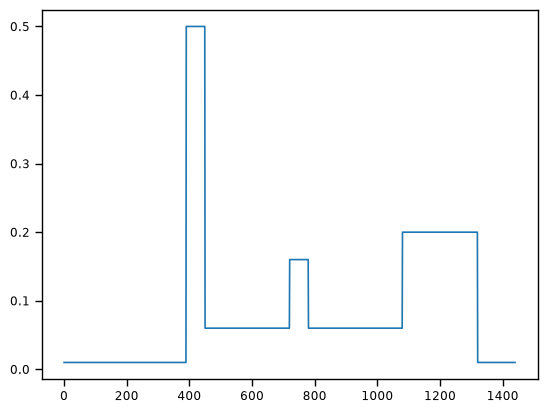

In [36]:
p_wd = OpenDHW.generate_daily_probability_step_function(
        mode='work-day',
        s_step=60,
        building_type="SFH",
    save_fig=True
    )

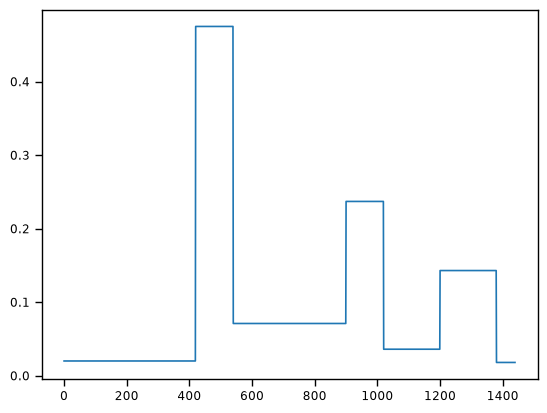

In [37]:
p_we = OpenDHW.generate_daily_probability_step_function(
        mode='off-day',
        s_step=60,
        building_type="SFH",
    save_fig=True
    )


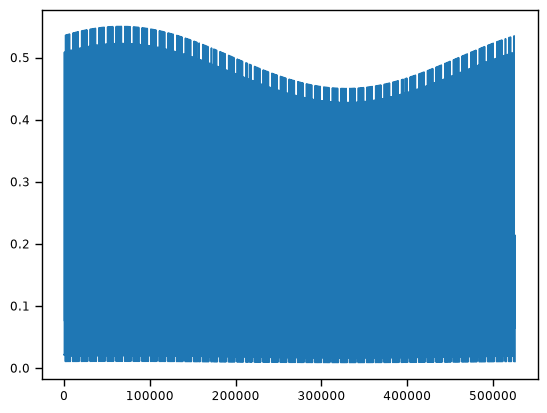

In [40]:
tzr = OpenDHW.generate_yearly_probabilities(initial_day=0,p_off_day=p_we,p_work_day=p_wd,s_step=60,building_type="SFH", holidays=holidays, plot_p_yearly=True)

In [39]:
tzr

[np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414213562373097),
 np.float64(0.021414

In [30]:
len(p_we)

24

In [31]:
sum(p_we)

2.545

In [23]:
tet=pd.Series(p_we)

In [25]:
from scipy.signal import resample
p_we_resampled = resample(tet, 24)

In [28]:
p_we_resampled

array([ 0.00203533,  0.03171946,  0.01014038,  0.02960812,  0.0090981 ,
        0.03519364, -0.00993832,  0.23377278,  0.550151  ,  0.24890561,
        0.04876694,  0.08029962,  0.06548334,  0.07587545,  0.0624041 ,
        0.14483468,  0.27180393,  0.12332734,  0.02923245,  0.03074307,
        0.08947995,  0.15042647,  0.14565945,  0.0859771 ])